# Compare old (buggy) vs new (fixed) `downsample()`

`overhead_pipeline.py::downsample()` used floor-division block sizes
(`H // out_h`, `W // out_w`) then cropped to `block_h*out_h x block_w*out_w`.
For a 104x256 mask downsampled to 18x44, `block_h = 104//18 = 5` (true ratio
~5.78) and `block_w = 256//44 = 5` (true ratio ~5.82) — so the code kept only
`arr[:90, :220]`, silently dropping the bottom ~13% and right ~14% of the mask.
Every `mask_true`/`y.npy` produced at 18x44 (via `notebooks/37_fix_downsample.ipynb`,
which calls this same function) inherited this shift.

The fix replaces the floor-division block reshape with `Image.resize(..., resample=Image.BOX)`,
which area-averages over the *entire* mask regardless of whether `out_h`/`out_w` evenly
divide the source dimensions.

This notebook re-implements the OLD buggy function locally (without touching
`overhead_pipeline.py`, which already has the fix) and compares it against the
NEW fixed version on real samples, overlaid on the actual segmentation mask and photo.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / 'src3'))

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from overhead_pipeline import downsample as downsample_new  # already fixed in overhead_pipeline.py

In [2]:
def downsample_old(mask: Image.Image, out_h: int, out_w: int) -> Image.Image:
    """The ORIGINAL buggy implementation, kept here only for comparison."""
    arr = np.array(mask, dtype=np.float32) / 255.0  # (H, W) in {0, 1}
    H, W = arr.shape
    block_h, block_w = H // out_h, W // out_w
    # BUG: floor division makes block_h*out_h / block_w*out_w undershoot H/W whenever
    # out_h/out_w don't evenly divide them, silently cropping the bottom/right edge
    # (13-14% of the mask for the 104x256 -> 18x44 case) instead of just losing a
    # sub-pixel remainder as the original comment claimed.
    arr = arr[:block_h * out_h, :block_w * out_w]
    downsampled_mask = arr.reshape(out_h, block_h, out_w, block_w).mean(axis=(1, 3))
    return Image.fromarray((downsampled_mask * 255).astype(np.uint8), mode="L")

In [3]:
SAMPLES_DIR = Path('/home/ethantu/workspace/good-vibrations/data/samples_overhead')
MASK_H, MASK_W = 18, 44

SAMPLE_IDS = [500, 469]  # known-good reference samples used to debug this

/tmp/ipykernel_601454/3587950582.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray((downsampled_mask * 255).astype(np.uint8), mode="L")


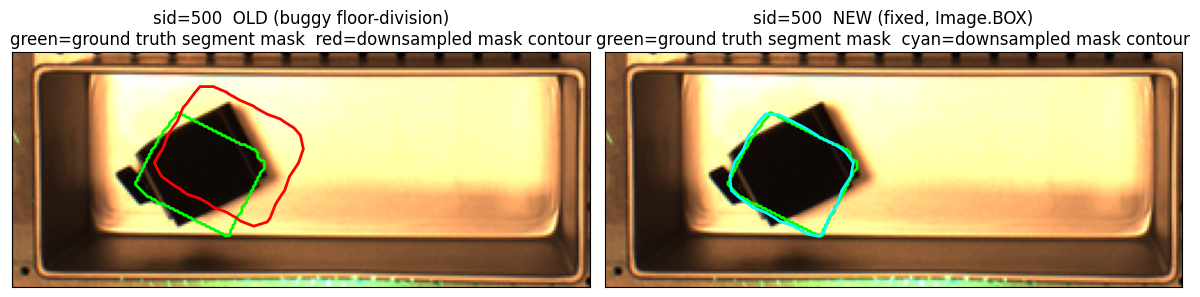

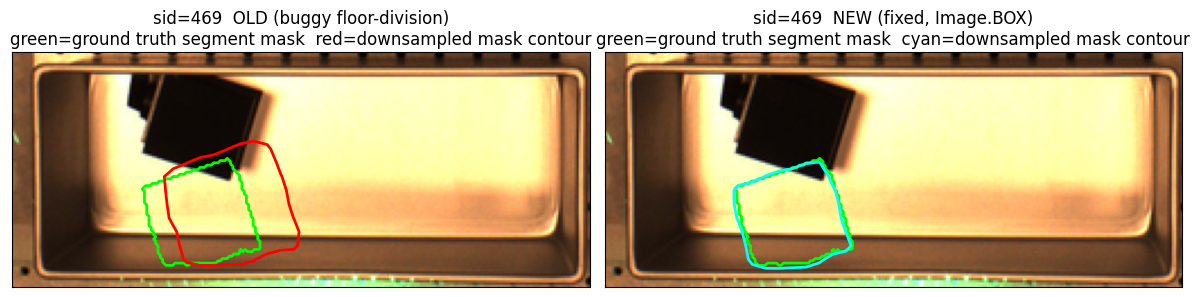

In [4]:
def compare_sample(sid: int):
    sample_dir = SAMPLES_DIR / f'{sid:06d}'
    img = Image.open(sample_dir / '01_resized_overhead.png').convert('RGB')
    photo_w, photo_h = img.size
    seg_img = Image.open(sample_dir / '02_segment_mask.png').convert('L')
    seg = np.asarray(seg_img) > 127

    old_mask = np.array(downsample_old(seg_img, MASK_H, MASK_W), dtype=np.float32) / 255.0
    new_mask = np.array(downsample_new(seg_img, MASK_H, MASK_W), dtype=np.float32) / 255.0

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, (name, mask_arr, color) in zip(
        axes,
        [('OLD (buggy floor-division)', old_mask, 'red'), ('NEW (fixed, Image.BOX)', new_mask, 'cyan')],
    ):
        ax.imshow(img, extent=(0, photo_w, photo_h, 0))
        ax.contour(seg, levels=[0.5], colors='lime', linewidths=2, extent=(0, seg_img.width, seg_img.height, 0))
        ax.contour(mask_arr, levels=[0.5], colors=color, linewidths=2, extent=(0, photo_w, photo_h, 0))
        ax.set_title(f'sid={sid}  {name}\ngreen=ground truth segment mask  {color}=downsampled mask contour')
        ax.set_xticks([]); ax.set_yticks([])
    fig.tight_layout()
    plt.show()

for sid in SAMPLE_IDS:
    compare_sample(sid)

## Quantitative check: bbox / COM shift

For each sample, compare the ground-truth segment mask's center of mass (scaled to
the 18x44 grid) against the OLD and NEW downsampled masks' own center of mass.

In [5]:
def com(mask_arr):
    s = mask_arr.sum()
    if s == 0: return float('nan'), float('nan')
    cy = float(np.average(np.arange(mask_arr.shape[0]), weights=mask_arr.sum(1)))
    cx = float(np.average(np.arange(mask_arr.shape[1]), weights=mask_arr.sum(0)))
    return cx, cy

for sid in SAMPLE_IDS:
    sample_dir = SAMPLES_DIR / f'{sid:06d}'
    seg_img = Image.open(sample_dir / '02_segment_mask.png').convert('L')
    seg_arr = np.asarray(seg_img, dtype=np.float32) / 255.0
    photo_w, photo_h = seg_img.size

    seg_cx, seg_cy = com(seg_arr)  # ground truth, in photo pixel space

    old_mask = np.array(downsample_old(seg_img, MASK_H, MASK_W), dtype=np.float32) / 255.0
    new_mask = np.array(downsample_new(seg_img, MASK_H, MASK_W), dtype=np.float32) / 255.0

    old_cx, old_cy = com(old_mask)
    new_cx, new_cy = com(new_mask)

    sx, sy = photo_w / MASK_W, photo_h / MASK_H
    old_cx_px, old_cy_px = old_cx * sx, old_cy * sy
    new_cx_px, new_cy_px = new_cx * sx, new_cy * sy

    print(f'sid={sid}')
    print(f'  ground truth com (photo px):  x={seg_cx:.1f}  y={seg_cy:.1f}')
    print(f'  OLD downsampled com (photo px, scaled): x={old_cx_px:.1f}  y={old_cy_px:.1f}   '
          f'error = ({old_cx_px-seg_cx:+.1f}, {old_cy_px-seg_cy:+.1f})')
    print(f'  NEW downsampled com (photo px, scaled): x={new_cx_px:.1f}  y={new_cy_px:.1f}   '
          f'error = ({new_cx_px-seg_cx:+.1f}, {new_cy_px-seg_cy:+.1f})')
    print()

sid=500
  ground truth com (photo px):  x=83.4  y=49.7
  OLD downsampled com (photo px, scaled): x=94.7  y=55.1   error = (+11.3, +5.4)
  NEW downsampled com (photo px, scaled): x=80.8  y=47.3   error = (-2.5, -2.3)

sid=469
  ground truth com (photo px):  x=83.4  y=31.1
  OLD downsampled com (photo px, scaled): x=94.8  y=33.7   error = (+11.3, +2.5)
  NEW downsampled com (photo px, scaled): x=80.8  y=28.6   error = (-2.6, -2.5)



/tmp/ipykernel_601454/3587950582.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray((downsampled_mask * 255).astype(np.uint8), mode="L")
